In [4]:
# Step 1: Installing the specialized Biopython framework to handle genomic text files
!pip install biopython pandas matplotlib

# Step 2: # Loading the NCBI Entrez API protocols into current RAM to establish a secure gateway with GenBank
from Bio import Entrez
from Bio import SeqIO
import pandas as pd
import matplotlib.pyplot as plt

print("Genomics libraries succesfully configured and synchronized!")

   ---------------------------------------- 0.0/2.7 MB ? eta -:--:--
   --------------- ------------------------ 1.0/2.7 MB 10.2 MB/s eta 0:00:01
   ---------------------------------------- 2.7/2.7 MB 10.5 MB/s  0:00:00
Genomics libraries succesfully configured and synchronized!


In [7]:
# Step 3: Tell the NCBI server who is asking for the data(mandatory safety rule)
Entrez.email = "gargeechoudhary05@gmail.com"

# Step 4: Downloading the raw text file (FASTA format) for the SARS-CoV-2 genome
handle = Entrez.efetch(db="nucleotide",id="NC_045512",rettype="fasta",retmode="text")
print("Connecting to NCBI GenBank servers...")

# Step 5: To read the genetic sequence out of the downloaded FASTA file
virus_record = SeqIO.read(handle,"fasta")
handle.close()

# Step 6: Calculating the length of the virus genome
genome_length = len(virus_record.seq)

print(f"\nSuccess! Successfully mined the full genome of: {virus_record.description}")
print(f"\Total RNA seq length: {genome_length} biological letters long.")

Connecting to NCBI GenBank servers...

Success! Successfully mined the full genome of: NC_045512.2 Severe acute respiratory syndrome coronavirus 2 isolate Wuhan-Hu-1, complete genome
\Total RNA seq length: 29903 biological letters long.


In [12]:
# Step 7: Accessing the raw string data from our virus record
dna_sequence = virus_record.seq

# Step 8: Counting the frequency of each individual nitrogenous base
base_counts = {
    'Adenine(A)': dna_sequence.count('A'),
    'Thymine(T)': dna_sequence.count ('T'),
    'Guanine(G)': dna_sequence.count('G'),
    'Cytosine(C)': dna_sequence.count('C')
}

# Step 9: Convert our count results into a clean pandas dataframe table
df_counts = pd.DataFrame(list(base_counts.items()), columns=["Nucleotide Base", "Frequency count"])

# Step 10: Calculating the overall GC content percentage mathematically
total_GC = base_counts['Guanine(G)'] + base_counts['Cytosine(C)']
GC_percentage = (total_GC/ genome_length)*100

# Step 11: Displaying my findings
print("==================== GENOMIC MATRIX ANALYSIS =====================")
print(df_counts.to_string(index=False))
print(f"\nOverall Structural GC content is: {GC_percentage:.2f}%")
print("==================================================================")

==================== GENOMIC MATRIX ANALYSIS =====================
Nucleotide Base  Frequency count
     Adenine(A)             8954
     Thymine(T)             9594
     Guanine(G)             5863
    Cytosine(C)             5492

Overall Structural GC content is: 37.97%


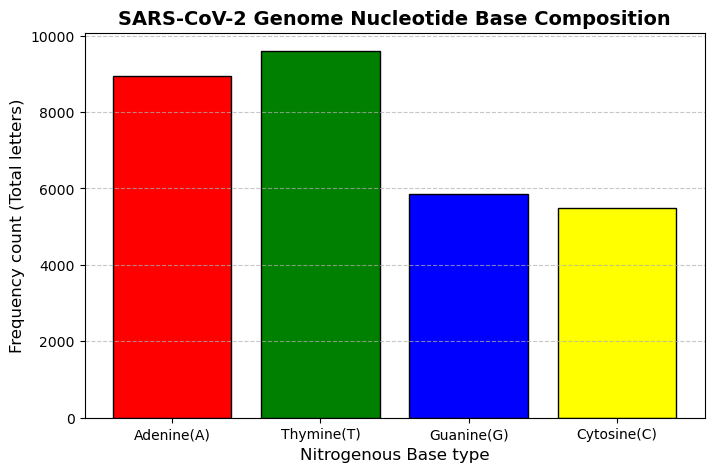

In [14]:
# Step 12: Configure the plot parameters using matplotlib
plt.figure(figsize=(8,5))
colors = ['red','green','blue','yellow']

# Step 13: Generating a Bar graph directly from my data table
plt.bar(df_counts ['Nucleotide Base'], df_counts ['Frequency count'], color=colors, edgecolor='black')

# Step 14: Adding Labels
plt.title("SARS-CoV-2 Genome Nucleotide Base Composition", fontsize=14, fontweight='bold')
plt.xlabel("Nitrogenous Base type", fontsize=12)
plt.ylabel("Frequency count (Total letters)", fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# FINAL STEP!! (render the graph on screen)
plt.show()